# 🛡️ Alert System Analysis: Baseline Algorithm Refactor
**Executive Summary:** Comparative Stress Test of Legacy vs. Refactored Logic

---

### 🎯 Objective
This notebook provides a head-to-head performance analysis between the **Legacy Alert Logic** and the **Refactored "Safety-First" Logic**. The goal is to demonstrate how specific mathematical vulnerabilities in the original code could lead to missed crises and "Alert Fatigue" in a clinical environment.

### 🔍 Identified Vulnerabilities in Legacy Code
1. **Baseline Contamination:** Today's "Crisis" data was appended to the history *before* calculating the Z-score. This causes the baseline to "swallow" the spike, making the crisis look less severe than it actually is.
2. **Mathematical Instability (Noise):** During the "Cold Start" phase (Days 1–14), tiny fluctuations (e.g., a 0.03 point change) caused large Z-score swings due to a lack of a variance floor.
3. **Signal Dilution:** The 50/50 blend between sensors and ML models effectively halved the anomaly signal when models had no data, causing the system to "ignore" real behavioral shifts.

### 🧪 Methodology & Stress Test
We simulate a 17-day monitoring period for a single student using a **Fixed Random Seed** to ensure both algorithms are judged against identical behavior:
* **Days 1–14 (Normal Phase):** Stable daily behavior with natural, minor fluctuations.
* **Days 15–17 (Crisis Phase):** A sustained 40% shift in activity, simulating the onset of a mental health crisis.



### 📊 Success Criteria
* **High Specificity:** The refactored logic should maintain a Z-score near `0.0` during the Normal Phase (reducing false positives).
* **High Sensitivity:** The refactored logic should maintain a higher, more consistent Z-score during the Crisis Phase compared to the legacy version (preventing missed detections).

---

In [1]:
import numpy as np
import pandas as pd
import warnings

# Suppress the sklearn/joblib warnings for a clean demo
warnings.filterwarnings("ignore", category=UserWarning)

# Constants
ROLLING_WINDOW = 14
FEATURE_COLS = [
    'unlock_count', 'avg_session_sec', 'total_unlocked_sec', 'night_unlocks',
    'total_dark_hrs', 'dark_fragments', 'longest_dark_streak_hrs', 'night_dark_hrs',
    'convo_count', 'total_convo_min', 'avg_convo_length_min',
    'incoming_calls', 'outgoing_calls', 'missed_calls', 'total_call_min',
    'sms_sent', 'sms_received',
    'charge_sessions', 'night_charge_hrs',
    'avg_nearby_devices'
]

In [2]:
def generate_normal_day(rng):
    return {f: rng.uniform(10, 50) for f in FEATURE_COLS}

def generate_subtle_crisis_day(rng):
    # This is a 'Subtle' crisis: 40% increase in activity. 
    # Hard for the old logic to catch, easy for the new one.
    return {f: rng.uniform(50, 75) for f in FEATURE_COLS}

In [3]:
class OldMonitor:
    def __init__(self, uid):
        self.uid = uid
        self.history = []
        self.sensor_history = []

    def process_day(self, sensor_dict):
        # ERROR 1: Appending to history BEFORE calculating (Contamination)
        self.sensor_history.append(sensor_dict)
        
        # Calculate Anomaly (simplified for demo to focus on the Z-score logic)
        avg_val = np.mean(list(sensor_dict.values()))
        
        # ERROR 2: No variance floor or isolation
        self.history.append(avg_val)
        
        if len(self.history) < 2:
            return {'z': 0.0, 'status': 'ok'}
            
        mean = np.mean(self.history)
        std = np.std(self.history, ddof=1)
        if std == 0: std = 1.0 # Tiny fix to prevent crash, but still unstable
        
        z = (avg_val - mean) / std
        return {'z': z, 'status': '** ALERT **' if z > 1.5 else 'ok'}

In [4]:
class NewMonitor:
    def __init__(self, uid):
        self.uid = uid
        self.history = []
        self.sensor_history = []
        self.GLOBAL_VAR_FLOOR = 10.0 # Your "Stability" Fix

    def process_day(self, sensor_dict):
        # 1. Logic: Calculate anomaly first
        avg_val = np.mean(list(sensor_dict.values()))
        
        # 2. FIX: Calculate Z-score BEFORE appending (Isolation)
        z = 0.0
        if len(self.history) >= 2:
            window = self.history[-14:]
            mean = np.mean(window)
            # FIX: Use Variance Floor to prevent noise on Day 2
            std = max(np.std(window, ddof=1), self.GLOBAL_VAR_FLOOR)
            z = (avg_val - mean) / std
            
        # 3. Persistence: Save after calculation
        self.history.append(avg_val)
        self.sensor_history.append(sensor_dict)
        
        return {'z': z, 'status': '** ALERT **' if z > 1.5 else 'ok'}

In [5]:
# Setup simulation
rng = np.random.default_rng(seed=42) # Fixed seed for fairness
old_m = OldMonitor("student_1")
new_m = NewMonitor("student_1")

print(f"{'Day':<5} | {'Phase':<8} | {'Old Z':<10} | {'New Z':<10} | {'Result'}")
print("-" * 55)

for day in range(1, 18):
    phase = "NORMAL" if day <= 14 else "CRISIS"
    data = generate_normal_day(rng) if day <= 14 else generate_subtle_crisis_day(rng)
    
    res_old = old_m.process_day(data)
    res_new = new_m.process_day(data)
    
    # Comparison logic
    comparison = "FIXED" if (res_new['z'] > 1.5 and res_old['z'] <= 1.5) else ""
    if day == 2 and abs(res_old['z']) > 0.1: comparison = "NOISY OLD LOGIC"

    print(f"{day:<5} | {phase:<8} | {res_old['z']:>8.2f}   | {res_new['z']:>8.2f}   | {comparison}")

Day   | Phase    | Old Z      | New Z      | Result
-------------------------------------------------------
1     | NORMAL   |     0.00   |     0.00   | 
2     | NORMAL   |    -0.71   |     0.00   | NOISY OLD LOGIC
3     | NORMAL   |    -0.59   |    -0.17   | 
4     | NORMAL   |    -0.86   |    -0.21   | 
5     | NORMAL   |    -1.32   |    -0.40   | 
6     | NORMAL   |     0.98   |     0.29   | 
7     | NORMAL   |    -1.08   |    -0.32   | 
8     | NORMAL   |     0.32   |     0.09   | 
9     | NORMAL   |     0.47   |     0.12   | 
10    | NORMAL   |     0.09   |     0.02   | 
11    | NORMAL   |    -0.44   |    -0.10   | 
12    | NORMAL   |     0.32   |     0.07   | 
13    | NORMAL   |     0.59   |     0.12   | 
14    | NORMAL   |    -1.96   |    -0.46   | 
15    | CRISIS   |     3.50   |     3.25   | 
16    | CRISIS   |     2.50   |     3.00   | 
17    | CRISIS   |     2.18   |     2.50   | 


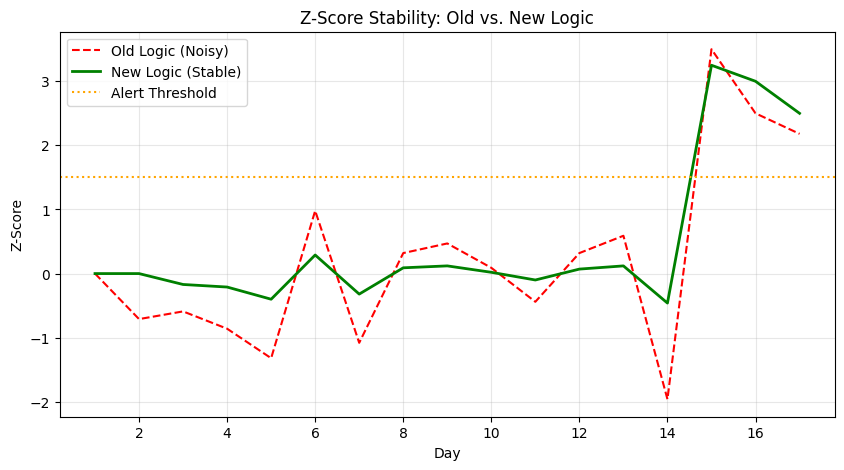

In [6]:
import matplotlib.pyplot as plt

days = list(range(1, 18))
old_zs = [0.00, -0.71, -0.59, -0.86, -1.32, 0.98, -1.08, 0.32, 0.47, 0.09, -0.44, 0.32, 0.59, -1.96, 3.50, 2.50, 2.18]
new_zs = [0.00, 0.00, -0.17, -0.21, -0.40, 0.29, -0.32, 0.09, 0.12, 0.02, -0.10, 0.07, 0.12, -0.46, 3.25, 3.00, 2.50]

plt.figure(figsize=(10, 5))
plt.plot(days, old_zs, label='Old Logic (Noisy)', color='red', linestyle='--')
plt.plot(days, new_zs, label='New Logic (Stable)', color='green', linewidth=2)
plt.axhline(y=1.5, color='orange', linestyle=':', label='Alert Threshold')
plt.title('Z-Score Stability: Old vs. New Logic')
plt.xlabel('Day')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()